# Лабораторная работа №4
## Поиск ассоциативных правил в транзакционных данных

**Цель:** Освоить методы поиска ассоциативных правил, реализовать ключевые
алгоритмы (Apriori, FP‑Growth), применить их к реальным и синтетическим наборам
данных, провести сравнительный анализ производительности и интерпретировать
полученные правила

## Задание 1. Реализация Apriori

In [1]:
import math # Импорт математических функций (используем ceil для округления порога поддержки вверх)
import itertools # Импорт инструментов для работы с итерациями (генерация комбинаций)
from collections import defaultdict # Импорт словаря со значением по умолчанию (удобно для счётчиков)
from typing import List, Dict, Tuple # Подсказки типов для строгой типизации

def normalize_transactions(transactions: List[List[str]]) -> List[List[str]]:
    """Удаляет дубликаты товаров внутри каждой транзакции и приводит к виду списка."""
    return [list(set(tx)) for tx in transactions] # Преобразуем в set (убираем повторы) и обратно в list

# ==============================================================================
# 1. APRIORI
# ==============================================================================
def apriori(transactions: List[List[str]], min_support: float) -> Dict[Tuple[str, ...], float]:
    """Классический Apriori с целочисленным подсчётом поддержки."""
    transactions = normalize_transactions(transactions) # Приводим данные к виду без дубликатов
    if not transactions: return {} # Защита от пустого входного датасета

    total_tx = len(transactions) # Считаем общее количество транзакций (N)
    min_count = math.ceil(min_support * total_tx) # Вычисляем минимальное абсолютное количество вхождений
    tx_sets = [set(tx) for tx in transactions] # Преобразуем транзакции в set для быстрого поиска подмножеств

    # L1: Ищем частые наборы размера 1 (отдельные товары)
    c1 = defaultdict(int) # Создаём счётчик: товар -> частота
    for tx in tx_sets:
        for item in tx: c1[item] += 1 # Проходим по всем товарам и считаем их вхождения

    # Фильтруем: оставляем только товары с поддержкой >= порога, ключом делаем frozenset
    l_k = {frozenset([item]): cnt for item, cnt in c1.items() if cnt >= min_count}
    # Сохраняем найденные наборы, переводя абсолютную частоту в относительную поддержку (0..1)
    all_freq = {tuple(sorted(fs)): cnt / total_tx for fs, cnt in l_k.items()}

    k = 2 # Начинаем искать наборы размера 2
    while l_k: # Цикл работает, пока на предыдущем шаге нашлись частые наборы
        # Join step: Генерация кандидатов размера k из частых наборов размера k-1
        c_k = set() # Множество для хранения кандидатов
        # Сортируем наборы для детерминированного порядка объединения
        l_items = sorted(l_k.keys(), key=lambda x: tuple(sorted(x)))
        for i in range(len(l_items)):
            for j in range(i + 1, len(l_items)):
                f1, f2 = l_items[i], l_items[j] # Берём два набора
                # Оптимизация Apriori: объединяем только если первые k-2 элемента совпадают
                if tuple(sorted(f1))[:-1] == tuple(sorted(f2))[:-1]:
                    union = f1 | f2 # Объединяем множества
                    if len(union) == k: c_k.add(union) # Если размер совпадает с k, добавляем кандидата

        # Prune step: Отсекаем кандидатов, у которых есть подмножество размера k-1, не являющееся частым
        valid_c = [c for c in c_k if all(frozenset(sub) in l_k for sub in itertools.combinations(c, k-1))]

        # Count step: Подсчёт поддержки каждого кандидата по всей базе
        c_counts = defaultdict(int)
        for tx in tx_sets:
            for c in valid_c:
                if c.issubset(tx): c_counts[c] += 1 # Проверяем вхождение кандидата в транзакцию

        # Filter & Store: Оставляем кандидатов с поддержкой >= min_count
        l_k = {c: cnt for c, cnt in c_counts.items() if cnt >= min_count}
        all_freq.update({tuple(sorted(c)): cnt / total_tx for c, cnt in l_k.items()}) # Обновляем итог
        k += 1 # Переходим к наборам следующего размера

    return all_freq # Возвращаем словарь: {кортеж_товаров: поддержка}

#

def generate_rules(
    frequent_itemsets: Dict[Tuple[str, ...], float],
    min_confidence: float,
    min_lift: float = 1.0,
    max_antecedent_len: int = None,
    max_consequent_len: int = None
) -> List[Tuple[Tuple[str, ...], Tuple[str, ...], float, float, float, float, float]]:
    """Генерация правил X → Y из частых наборов."""
    rules = [] # Инициализируем список правил

    for itemset, sup_xy in frequent_itemsets.items(): # Перебираем частые наборы
        n = len(itemset)
        if n < 2: continue # Пропускаем наборы < 2 элементов

        # Перебираем размеры антецедента (от 1 до n-1)
        for r in range(1, n):
            for antecedent in itertools.combinations(itemset, r):
                # Консеквент = оставшиеся элементы набора
                consequent = tuple(sorted(set(itemset) - set(antecedent)))

                # Фильтрация по максимальной длине частей правила
                if max_antecedent_len is not None and len(antecedent) > max_antecedent_len: continue
                if max_consequent_len is not None and len(consequent) > max_consequent_len: continue

                # Получаем поддержки антецедента и консеквента
                sup_x = frequent_itemsets.get(antecedent)
                sup_y = frequent_itemsets.get(consequent)
                if sup_x is None or sup_y is None: continue # Если поднабор не частый, правило невалидно

                confidence = sup_xy / sup_x # P(Y|X) = P(X∩Y) / P(X)
                lift = confidence / sup_y    # Lift = P(Y|X) / P(Y)
                leverage = sup_xy - (sup_x * sup_y)  # P(X∩Y) - P(X)P(Y)

                # Применяем пороги отбора
                if confidence < min_confidence: continue
                if lift < min_lift: continue

                # Conviction: (1 - P(Y)) / (1 - Conf). При conf=1.0 → ∞
                if confidence == 1.0:
                    conviction = float('inf')
                else:
                    conviction = (1.0 - sup_y) / (1.0 - confidence)

                # Сохраняем кортеж метрик
                rules.append((antecedent, consequent, sup_xy, confidence, lift, conviction, leverage))

    return rules # Возвращаем отфильтрованные правила

## Задание 2. Реализация FP‑Growth

In [2]:
import itertools
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Any

# ==============================================================================
# 2. FP-GROWTH
# ==============================================================================
class FPNode:
    __slots__ = ('item', 'count', 'parent', 'children', 'node_link')
    def __init__(self, item: Optional[str] = None, count: int = 1, parent: Optional['FPNode'] = None):
        self.item = item # Хранимый товар
        self.count = count # Частота узла
        self.parent = parent # Родитель
        self.children: Dict[str, 'FPNode'] = {} # Дочерние узлы
        self.node_link: Optional['FPNode'] = None # Ссылка для Header Table

def fpgrowth(transactions: List[List[str]], min_support: float) -> Dict[Tuple[str, ...], float]:
    """FP-Growth с целочисленным подсчётом."""
    transactions = normalize_transactions(transactions)
    if not transactions: return {}

    total_tx = len(transactions)
    min_count = math.ceil(min_support * total_tx)

    # 1. Глобальные частоты
    freq = defaultdict(int)
    for tx in transactions:
        for item in tx: freq[item] += 1

    frequent = {item: c for item, c in freq.items() if c >= min_count}
    if not frequent: return {}

    # Сортировка товаров по убыванию частоты
    sorted_items = sorted(frequent.keys(), key=lambda x: (-frequent[x], x))
    item_rank = {item: i for i, item in enumerate(sorted_items)}
    header_table = {item: [frequent[item], None] for item in sorted_items} # Таблица указателей
    root = FPNode("null") # Корень дерева

    # 2. Построение FP-дерева
    for tx in transactions:
        # Фильтруем и сортируем транзакцию по частоте товаров
        filtered = sorted([item for item in tx if item in frequent], key=lambda x: item_rank[x])
        if not filtered: continue

        curr = root
        for item in filtered:
            if item in curr.children:
                curr.children[item].count += 1
            else:
                curr.children[item] = FPNode(item, 1, curr)
                # Обновляем цепочку в Header Table
                if header_table[item][1] is None:
                    header_table[item][1] = curr.children[item]
                else:
                    tail = header_table[item][1]
                    while tail.node_link: tail = tail.node_link
                    tail.node_link = curr.children[item]
            curr = curr.children[item]

    # 3. Рекурсивный майнинг
    freq_sets: Dict[Tuple[str, ...], int] = {}
    _mine_tree(root, header_table, [], freq_sets, min_count)
    return {p: c / total_tx for p, c in freq_sets.items()} # Возвращаем поддержку

def _mine_tree(node: FPNode, header_table: Dict, prefix: List[str], freq_sets: Dict, min_count: int):
    """Рекурсивный обход дерева."""
    items = sorted(header_table.keys(), key=lambda x: header_table[x][0])

    for item in items:
        base_count = header_table[item][0]
        if base_count < min_count: continue

        # Записываем новый частый набор
        freq_sets[tuple(sorted(prefix + [item]))] = base_count

        # Собираем условную базу
        cond_base = []
        curr = header_table[item][1]
        while curr:
            path = []
            parent = curr.parent
            while parent.item != "null":
                path.append(parent.item)
                parent = parent.parent
            if path: cond_base.append((path, curr.count))
            curr = curr.node_link

        if not cond_base: continue

        # Считаем частоты в условной базе
        cond_freq = defaultdict(int)
        for path, cnt in cond_base:
            for i in path: cond_freq[i] += cnt

        valid = {i: c for i, c in cond_freq.items() if c >= min_count}
        if not valid: continue

        # Строим условное дерево
        sorted_valid = sorted(valid.keys(), key=lambda x: (-valid[x], x))
        cond_rank = {i: idx for idx, i in enumerate(sorted_valid)}
        cond_header = {i: [valid[i], None] for i in sorted_valid}
        cond_root = FPNode("null")

        for path, cnt in cond_base:
            filtered = sorted([i for i in path if i in valid], key=lambda x: cond_rank[x])
            if not filtered: continue

            curr = cond_root
            for i in filtered:
                if i in curr.children: curr.children[i].count += cnt
                else:
                    curr.children[i] = FPNode(i, cnt, curr)
                    if cond_header[i][1] is None: cond_header[i][1] = curr.children[i]
                    else:
                        tail = cond_header[i][1]
                        while tail.node_link: tail = tail.node_link
                        tail.node_link = curr.children[i]
                curr = curr.children[i]

        _mine_tree(cond_root, cond_header, prefix + [item], freq_sets, min_count)

#


def generate_rules_fp(
    frequent_itemsets: Dict[Tuple[str, ...], float],
    min_confidence: float,
    min_lift: float = 1.0,
    max_antecedent_len: Optional[int] = None,
    max_consequent_len: Optional[int] = None
) -> List[Tuple[Tuple[str, ...], Tuple[str, ...], float, float, float, float, float]]:
    """
    Генерация ассоциативных правил из словаря частых наборов, полученного FP-Growth.
    Формат вывода идентичен Apriori для удобства сравнительного анализа.
    """
    rules = []
    for itemset, sup_xy in frequent_itemsets.items():
        n = len(itemset)
        if n < 2:
            continue

        for r in range(1, n):
            for antecedent in itertools.combinations(itemset, r):
                consequent = tuple(sorted(set(itemset) - set(antecedent)))

                if max_antecedent_len is not None and len(antecedent) > max_antecedent_len:
                    continue
                if max_consequent_len is not None and len(consequent) > max_consequent_len:
                    continue

                sup_x = frequent_itemsets.get(antecedent)
                sup_y = frequent_itemsets.get(consequent)
                if sup_x is None or sup_y is None:
                    continue

                confidence = sup_xy / sup_x
                lift = confidence / sup_y
                if lift < min_lift:
                    continue
                if confidence < min_confidence:
                    continue

                leverage = sup_xy - (sup_x * sup_y)
                conviction = float('inf') if confidence == 1.0 else (1.0 - sup_y) / (1.0 - confidence)

                rules.append((antecedent, consequent, sup_xy, confidence, lift, conviction, leverage))

    return rules

## Задание 3: Загрузка и предобработка данных
### Используется датасет Online Retail (Интернет торговля):
- InvoiceNo (Номер счета) — Уникальный идентификатор транзакции (чека).
- StockCode (Код товара) — Уникальный идентификатор конкретного продукта в системе магазина.
- Description (Описание) — Название или описание товара.
- Quantity (Количество) — Сколько штук данного товара было куплено в рамках этой транзакции.
- InvoiceDate (Дата счета) — Дата и время совершения покупки.
- UnitPrice (Цена за единицу) — Стоимость одной единицы товара.
- CustomerID (ID клиента) — Уникальный идентификатор покупателя (клиента).
- Country (Страна) — Страна, в которой произошел платеж.

Исходный размер: 479173 строк, 8 колонок
 Удалено строк с пропусками: 118227
Удалены отменённые заказы (начинающиеся с 'C')
 Оставлены строки с Quantity >= 1
Сформировано транзакций: 16634

БАЗОВАЯ СТАТИСТИКА ПО ДАТАСЕТУ
Количество транзакций:        16,634
Уникальных товаров (StockCode): 3,639
Средняя длина транзакции:     21.21 ± 23.92
Диапазон длин:                [1, 542]
Всего покупок (строки):       352,798
Разреженность матрицы:        99.42%

 Топ-5 частых товаров:
   1. 85123A: 1881 вхождений
   2. 22423: 1601 вхождений
   3. 85099B: 1497 вхождений
   4. 47566: 1349 вхождений
   5. 84879: 1282 вхождений



C:\Users\1\AppData\Local\Temp\ipykernel_5576\3855760294.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, x='Frequency', y='StockCode', ax=axes[1], palette='viridis')


 Графики сохранены: retail_stats.png


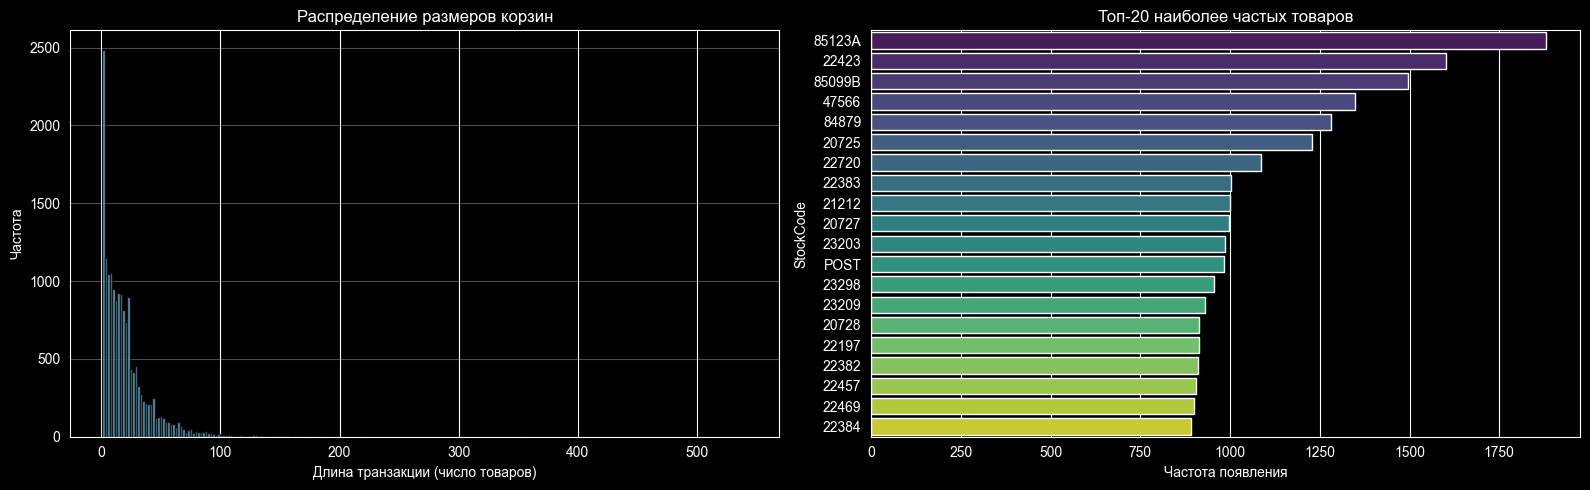

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from typing import List, Tuple, Dict

def load_and_preprocess(filepath: str,
                        min_quantity: int = 1,
                        remove_cancellations: bool = True,
                        country_filter: str = None) -> Tuple[pd.DataFrame, List[List[str]]]:
    """
    Загрузка и предобработка данных для association rule mining.

    Параметры:
        filepath: путь к Excel/CSV файлу
        min_quantity: минимальное количество товара в строке (по умолчанию >=1)
        remove_cancellations: удалять ли отменённые заказы (инвойсы, начинающиеся с 'C')
        country_filter: опциональная фильтрация по стране (например, 'United Kingdom')

    Возвращает:
        df_clean: очищенный DataFrame
        transactions: список транзакций, где каждая — список StockCode
    """
    # Определение типа файла
    if filepath.endswith('.xlsx'):
        df = pd.read_excel(filepath, dtype={'InvoiceNo': str, 'StockCode': str, 'CustomerID': str})
    else:
        df = pd.read_csv(filepath, dtype={'InvoiceNo': str, 'StockCode': str, 'CustomerID': str},
                         encoding='latin-1')  # Для корректного чтения описаний

    print(f"Исходный размер: {df.shape[0]} строк, {df.shape[1]} колонок")

    # ================= 1. Удаление пропусков =================
    # StockCode и InvoiceNo критичны, Description можно восстановить по коду, CustomerID — опционален
    #initial_len = len(df)
    #df = df.dropna(subset=['InvoiceNo', 'StockCode', 'Description'])
    #print(f" Удалено строк с пропусками в ключевых полях: {initial_len - len(df)}")
    initial_len = len(df)
    df = df.dropna()  # Удаление
    print(f" Удалено строк с пропусками: {initial_len - len(df)}")

    # ================= 2. Фильтрация по количеству и отменам =================
    if remove_cancellations:
        # Отменённые инвойсы обычно начинаются с 'C'
        df = df[~df['InvoiceNo'].str.startswith('C', na=False)]
        print(f"Удалены отменённые заказы (начинающиеся с 'C')")

    if min_quantity > 0:
        df = df[df['Quantity'] >= min_quantity]
        print(f" Оставлены строки с Quantity >= {min_quantity}")

    # Убираем отрицательные цены (возвраты/ошибки)
    df = df[df['UnitPrice'] > 0]

    # ================= 3. Опциональная фильтрация по стране =================
    if country_filter:
        df = df[df['Country'] == country_filter]
        print(f"Отфильтровано по стране: {country_filter}")

    # ================= 4. Приведение к транзакциям (группировка по InvoiceNo) =================
    # Каждая транзакция — набор уникальных StockCode
    transactions_df = df.groupby('InvoiceNo')['StockCode'].apply(list).reset_index()
    transactions = transactions_df['StockCode'].tolist()

    print(f"Сформировано транзакций: {len(transactions)}")
    return df, transactions


def compute_statistics(transactions: List[List[str]], top_n: int = 20) -> Dict:
    """
    Расчёт базовой статистики по набору транзакций.

    Возвращает словарь со статистикой и DataFrame с топ-элементами.
    """
    # Уникальные элементы
    all_items = [item for tx in transactions for item in tx]
    unique_items = set(all_items)

    # Длина транзакций
    tx_lengths = [len(tx) for tx in transactions]

    # Частоты элементов
    item_freq = Counter(all_items)

    stats = {
        'n_transactions': len(transactions),
        'n_unique_items': len(unique_items),
        'avg_tx_length': np.mean(tx_lengths),
        'std_tx_length': np.std(tx_lengths),
        'min_tx_length': min(tx_lengths),
        'max_tx_length': max(tx_lengths),
        'total_item_occurrences': len(all_items),
        'sparsity': 1 - len(all_items) / (len(transactions) * len(unique_items)),
        'top_items': item_freq.most_common(top_n)
    }

    # DataFrame для визуализации топ-элементов
    df_top = pd.DataFrame(stats['top_items'], columns=['StockCode', 'Frequency'])

    return stats, df_top


def plot_frequency_distribution(transactions: List[List[str]], df_top: pd.DataFrame, save_path: str = None):
    """
    Визуализация: гистограмма длин транзакций + барчарт топ-элементов.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 1. Распределение длин транзакций
    tx_lengths = [len(tx) for tx in transactions]
    axes[0].hist(tx_lengths, bins='auto', edgecolor='black', alpha=0.7, color='skyblue')
    axes[0].set_xlabel('Длина транзакции (число товаров)')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Распределение размеров корзин')
    axes[0].grid(axis='y', alpha=0.3)

    # 2. Топ-20 частых товаров
    sns.barplot(data=df_top, x='Frequency', y='StockCode', ax=axes[1], palette='viridis')
    axes[1].set_xlabel('Частота появления')
    axes[1].set_ylabel('StockCode')
    axes[1].set_title(f'Топ-{len(df_top)} наиболее частых товаров')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f" Графики сохранены: {save_path}")
    plt.show()


# ================= ЗАПУСК Пайплайна =================
if __name__ == "__main__":

    FILE_PATH = "C:/Users/1/PycharmProjects/IAD_4sem/data/Online Retail 2.xlsx"

    # 1. Загрузка и предобработка
    df_clean, transactions = load_and_preprocess(
        filepath=FILE_PATH,
        min_quantity=1,
        remove_cancellations=True,
        country_filter=None
    )

    # 2. Расчёт статистики
    stats, df_top = compute_statistics(transactions, top_n=20)

    # 3. Вывод ключевых метрик
    print("\n" + "="*60)
    print("БАЗОВАЯ СТАТИСТИКА ПО ДАТАСЕТУ")
    print("="*60)
    print(f"Количество транзакций:        {stats['n_transactions']:,}")
    print(f"Уникальных товаров (StockCode): {stats['n_unique_items']:,}")
    print(f"Средняя длина транзакции:     {stats['avg_tx_length']:.2f} ± {stats['std_tx_length']:.2f}")
    print(f"Диапазон длин:                [{stats['min_tx_length']}, {stats['max_tx_length']}]")
    print(f"Всего покупок (строки):       {stats['total_item_occurrences']:,}")
    print(f"Разреженность матрицы:        {stats['sparsity']*100:.2f}%")
    print(f"\n Топ-5 частых товаров:")
    for i, (code, freq) in enumerate(stats['top_items'][:5], 1):
        print(f"   {i}. {code}: {freq} вхождений")
    print("="*60 + "\n")

    # 4. Визуализация
        # 4. Визуализация
    plot_frequency_distribution(transactions, df_top, save_path="retail_stats.png")

    # 5. Сохранение предобработанных транзакций для дальнейшей работы
    import pickle
    with open("transactions_preprocessed.pkl", "wb") as f:
        pickle.dump(transactions, f)

## Задание 4: Эксперименты с параметрами

 Запуск серии экспериментов...
 Транзакций: 16634
 Параметры: min_support ∈ [0.05, 0.03, 0.02, 0.01], min_confidence ∈ [0.5, 0.7, 0.9]

 min_support = 0.050
   Apriori: 20 наборов за 0.30 сек
   FP-Growth: 20 наборов за 0.12 сек

 min_support = 0.030
   Apriori: 98 наборов за 4.86 сек
   FP-Growth: 98 наборов за 0.52 сек

 min_support = 0.020
   Apriori: 254 наборов за 25.87 сек
   FP-Growth: 254 наборов за 0.93 сек

 min_support = 0.010
   Apriori: 1044 наборов за 487.58 сек
   FP-Growth: 1044 наборов за 2.45 сек
Графики сохранены: experiment_results.png


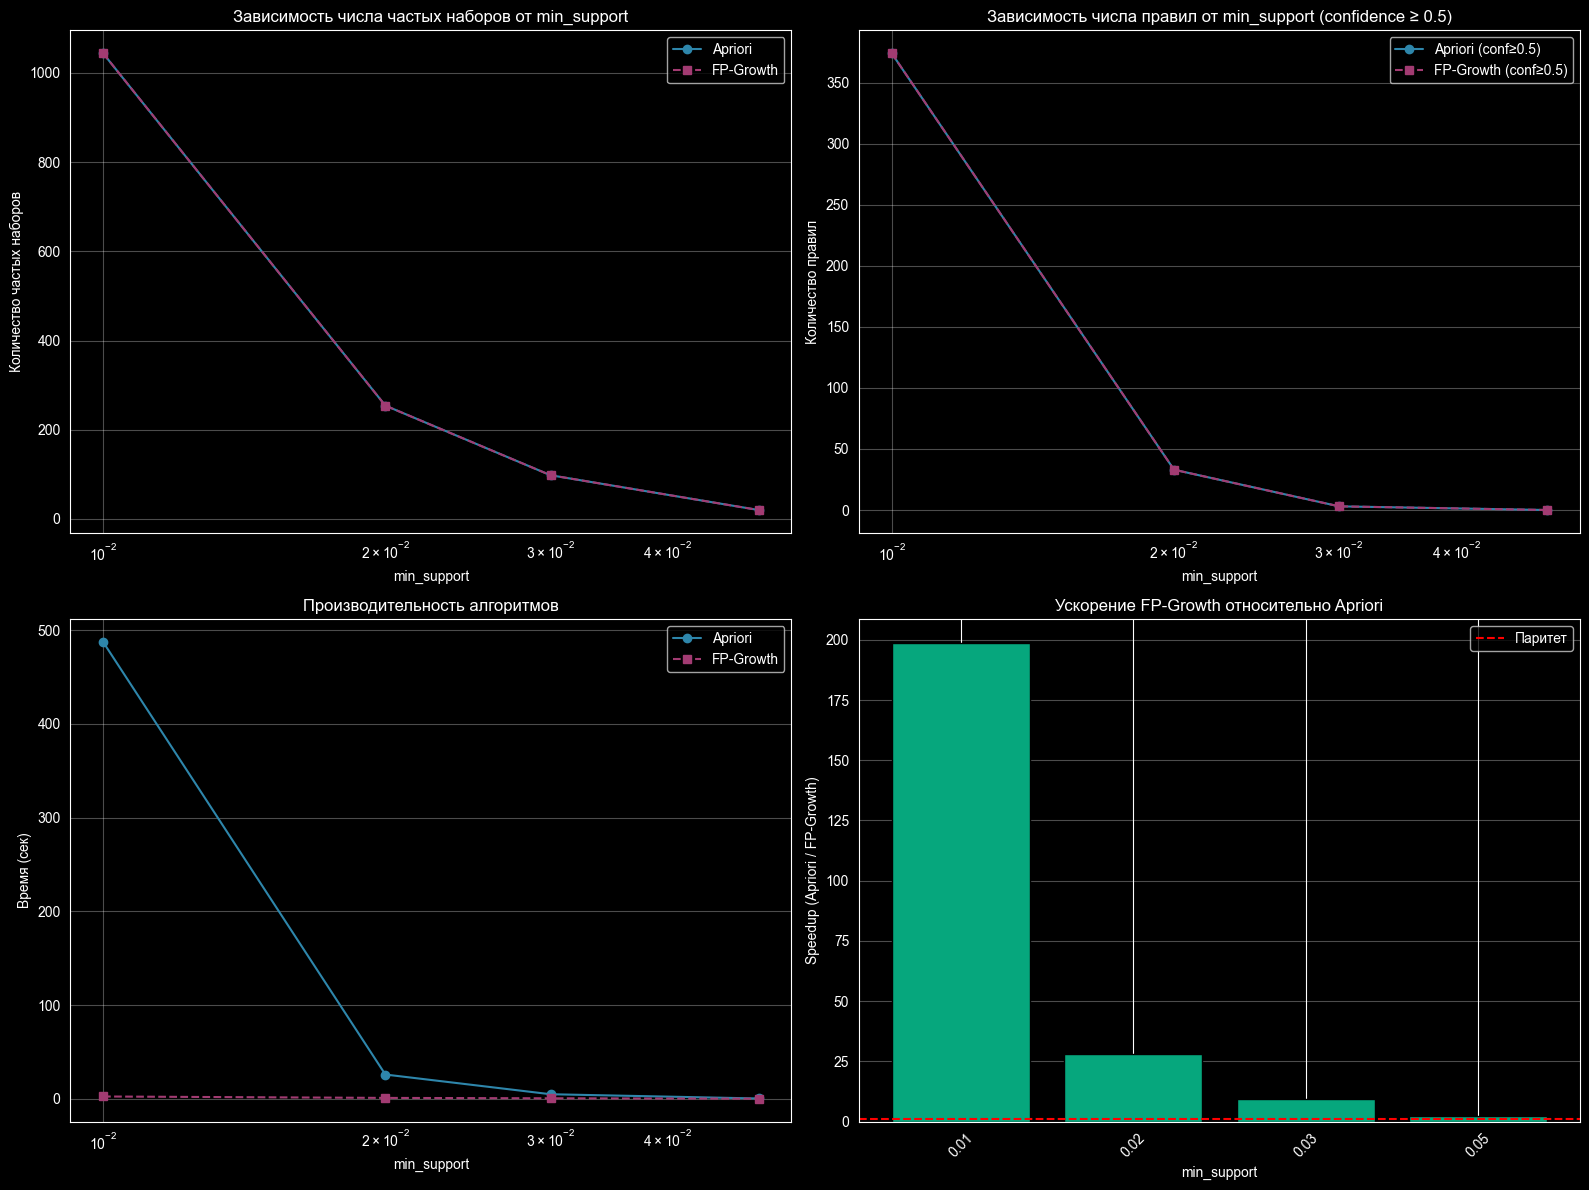


 ТОП-10 ПРАВИЛ | FPGROWTH | min_sup=0.01, min_conf=0.5

 По Lift (наибольшая корреляция):
№   Правило                                      Lift     Conf      Sup
----------------------------------------------------------------------
1   23172 → 23170∧23171            64.242    0.861    0.011
2   23170∧23171 → 23172                  64.242    0.807    0.011
3   23171 → 23170∧23172            61.642    0.700    0.011
4   23170∧23172 → 23171                  61.642    0.952    0.011
5   23171 → 23172                  59.459    0.747    0.012
6   23172 → 23171                  59.459    0.919    0.012
7   22745∧22748 → 22746                  52.487    0.742    0.011
8   22746 → 22745∧22748            52.487    0.745    0.011
9   23170 → 23171∧23172            50.467    0.583    0.011
10  23171∧23172 → 23170                  50.467    0.937    0.011

По Confidence (наибольшая точность):
№   Правило                                      Lift     Conf      Sup
--------------------------------

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from typing import Dict, List, Tuple
from collections import defaultdict
import math



def run_experiment(
    transactions: List[List[str]],
    min_support_values: List[float],
    min_confidence_values: List[float],
    algorithm: str = 'both',
    min_lift: float = 1.0,
    max_antecedent_len: int = 3,
    max_consequent_len: int = 2
) -> Dict:
    """
    Проведение серии экспериментов с Apriori и/или FP-Growth.

    Returns:
        dict с результатами: времена, количество наборов/правил, топ-правила
    """
    results = defaultdict(dict)

    for min_sup in min_support_values:
        print(f"\n min_support = {min_sup:.3f}")

        # ================= Apriori =================
        if algorithm in ['apriori', 'both']:
            start = time.time()
            freq_apriori = apriori(transactions, min_support=min_sup)
            time_apriori = time.time() - start

            results[min_sup]['apriori_time'] = time_apriori
            results[min_sup]['apriori_itemsets'] = len(freq_apriori)
            print(f"   Apriori: {len(freq_apriori)} наборов за {time_apriori:.2f} сек")

            # Генерация правил для разных confidence
            for min_conf in min_confidence_values:
                rules = generate_rules(
                    freq_apriori,
                    min_confidence=min_conf,
                    min_lift=min_lift,
                    max_antecedent_len=max_antecedent_len,
                    max_consequent_len=max_consequent_len
                )
                key = f'apriori_conf_{min_conf}'
                results[min_sup][key] = len(rules)

                # Сохраняем топ-10 правил по lift для отчёта
                if rules and min_conf == min_confidence_values[0]:  # только для первой конф.
                    df_rules = pd.DataFrame(rules, columns=[
                        "antecedent", "consequent", "support", "confidence",
                        "lift", "conviction", "leverage"
                    ])
                    results[min_sup][f'{key}_top_lift'] = df_rules.nlargest(10, 'lift').to_dict('records')

        # ================= FP-Growth =================
        if algorithm in ['fpgrowth', 'both']:
            start = time.time()
            freq_fpgrowth = fpgrowth(transactions, min_support=min_sup)
            time_fpgrowth = time.time() - start

            results[min_sup]['fpgrowth_time'] = time_fpgrowth
            results[min_sup]['fpgrowth_itemsets'] = len(freq_fpgrowth)
            print(f"   FP-Growth: {len(freq_fpgrowth)} наборов за {time_fpgrowth:.2f} сек")

            # Проверка идентичности результатов
            if algorithm == 'both' and min_sup in results:
                match = set(freq_apriori.keys()) == set(freq_fpgrowth.keys())
                results[min_sup]['results_match'] = match
                if not match:
                    print(f"    Расхождение в наборах! Apriori: {len(freq_apriori)}, FP-Growth: {len(freq_fpgrowth)}")

            for min_conf in min_confidence_values:
                rules = generate_rules_fp(
                    freq_fpgrowth,
                    min_confidence=min_conf,
                    min_lift=min_lift,
                    max_antecedent_len=max_antecedent_len,
                    max_consequent_len=max_consequent_len
                )
                key = f'fpgrowth_conf_{min_conf}'
                results[min_sup][key] = len(rules)

                if rules and min_conf == min_confidence_values[0]:
                    df_rules = pd.DataFrame(rules, columns=[
                        "antecedent", "consequent", "support", "confidence",
                        "lift", "conviction", "leverage"
                    ])
                    results[min_sup][f'{key}_top_lift'] = df_rules.nlargest(10, 'lift').to_dict('records')

    return dict(results)


def plot_experiment_results(results: Dict, save_path: str = None):
    """
    Визуализация:
    1. Количество частых наборов vs min_support
    2. Количество правил vs min_support (для разных confidence)
    3. Время работы алгоритмов
    """
    min_sup_values = sorted(results.keys())

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    colors = {'apriori': '#2E86AB', 'fpgrowth': '#A23B72'}

    # 1. Частые наборы
    ax = axes[0, 0]
    if 'apriori_itemsets' in results[min_sup_values[0]]:
        apriori_counts = [results[s]['apriori_itemsets'] for s in min_sup_values]
        ax.plot(min_sup_values, apriori_counts, 'o-', label='Apriori', color=colors['apriori'])
    if 'fpgrowth_itemsets' in results[min_sup_values[0]]:
        fpgrowth_counts = [results[s]['fpgrowth_itemsets'] for s in min_sup_values]
        ax.plot(min_sup_values, fpgrowth_counts, 's--', label='FP-Growth', color=colors['fpgrowth'])
    ax.set_xlabel('min_support')
    ax.set_ylabel('Количество частых наборов')
    ax.set_title('Зависимость числа частых наборов от min_support')
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.legend()

    # 2. Количество правил (для confidence=0.5)
    ax = axes[0, 1]
    conf = 0.5
    if f'apriori_conf_{conf}' in results[min_sup_values[0]]:
        apriori_rules = [results[s].get(f'apriori_conf_{conf}', 0) for s in min_sup_values]
        ax.plot(min_sup_values, apriori_rules, 'o-', label=f'Apriori (conf≥{conf})', color=colors['apriori'])
    if f'fpgrowth_conf_{conf}' in results[min_sup_values[0]]:
        fpgrowth_rules = [results[s].get(f'fpgrowth_conf_{conf}', 0) for s in min_sup_values]
        ax.plot(min_sup_values, fpgrowth_rules, 's--', label=f'FP-Growth (conf≥{conf})', color=colors['fpgrowth'])
    ax.set_xlabel('min_support')
    ax.set_ylabel('Количество правил')
    ax.set_title(f'Зависимость числа правил от min_support (confidence ≥ {conf})')
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.legend()

    # 3. Время работы
    ax = axes[1, 0]
    if 'apriori_time' in results[min_sup_values[0]]:
        apriori_times = [results[s]['apriori_time'] for s in min_sup_values]
        ax.plot(min_sup_values, apriori_times, 'o-', label='Apriori', color=colors['apriori'])
    if 'fpgrowth_time' in results[min_sup_values[0]]:
        fpgrowth_times = [results[s]['fpgrowth_time'] for s in min_sup_values]
        ax.plot(min_sup_values, fpgrowth_times, 's--', label='FP-Growth', color=colors['fpgrowth'])
    ax.set_xlabel('min_support')
    ax.set_ylabel('Время (сек)')
    ax.set_title('Производительность алгоритмов')
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.legend()

    # 4. Отношение времени (speedup FP-Growth / Apriori)
    ax = axes[1, 1]
    speedups = []
    valid_sup = []
    for s in min_sup_values:
        if 'apriori_time' in results[s] and 'fpgrowth_time' in results[s]:
            if results[s]['fpgrowth_time'] > 0:
                speedup = results[s]['apriori_time'] / results[s]['fpgrowth_time']
                speedups.append(speedup)
                valid_sup.append(s)

    if speedups:
        ax.bar([str(round(s, 3)) for s in valid_sup], speedups, color='#06A77D', edgecolor='black')
        ax.axhline(y=1, color='red', linestyle='--', label='Паритет')
        ax.set_xlabel('min_support')
        ax.set_ylabel('Speedup (Apriori / FP-Growth)')
        ax.set_title('Ускорение FP-Growth относительно Apriori')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        ax.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Графики сохранены: {save_path}")
    plt.show()


def print_top_rules(results: Dict, min_support: float, algorithm: str = 'fpgrowth',
                    min_confidence: float = 0.5, top_n: int = 10):
    """
    Вывод топ-правил по lift, confidence и leverage для заданных параметров.
    """
    print(f"\n{'='*70}")
    print(f" ТОП-{top_n} ПРАВИЛ | {algorithm.upper()} | min_sup={min_support}, min_conf={min_confidence}")
    print(f"{'='*70}")

    key = f'{algorithm}_conf_{min_confidence}_top_lift'
    if key not in results[min_support]:
        print(" Правила для этих параметров не найдены или не сохранены.")
        return

    top_rules = results[min_support][key]

    # По Lift
    print(f"\n По Lift (наибольшая корреляция):")
    print(f"{'№':<3} {'Правило':<40} {'Lift':>8} {'Conf':>8} {'Sup':>8}")
    print("-"*70)
    for i, rule in enumerate(sorted(top_rules, key=lambda x: -x['lift'])[:top_n], 1):
        ante = '∧'.join(rule['antecedent'][:2]) + ('...' if len(rule['antecedent'])>2 else '')
        cons = '∧'.join(rule['consequent'][:2])
        print(f"{i:<3} {ante} → {cons:<20} {rule['lift']:>8.3f} {rule['confidence']:>8.3f} {rule['support']:>8.3f}")

    # По Confidence
    print(f"\nПо Confidence (наибольшая точность):")
    print(f"{'№':<3} {'Правило':<40} {'Lift':>8} {'Conf':>8} {'Sup':>8}")
    print("-"*70)
    for i, rule in enumerate(sorted(top_rules, key=lambda x: -x['confidence'])[:top_n], 1):
        ante = '∧'.join(rule['antecedent'][:2]) + ('...' if len(rule['antecedent'])>2 else '')
        cons = '∧'.join(rule['consequent'][:2])
        print(f"{i:<3} {ante} → {cons:<20} {rule['lift']:>8.3f} {rule['confidence']:>8.3f} {rule['support']:>8.3f}")

    # По Leverage
    print(f"\n По Leverage (наибольший практический эффект):")
    print(f"{'№':<3} {'Правило':<40} {'Lift':>8} {'Conf':>8} {'Lev':>10}")
    print("-"*70)
    for i, rule in enumerate(sorted(top_rules, key=lambda x: -x['leverage'])[:top_n], 1):
        ante = '∧'.join(rule['antecedent'][:2]) + ('...' if len(rule['antecedent'])>2 else '')
        cons = '∧'.join(rule['consequent'][:2])
        print(f"{i:<3} {ante} → {cons:<20} {rule['lift']:>8.3f} {rule['confidence']:>8.3f} {rule['leverage']:>10.4f}")


# ================= ЗАПУСК ЭКСПЕРИМЕНТОВ =================
if __name__ == "__main__":
    # Параметры эксперимента
    MIN_SUPPORT_VALUES = [0.05, 0.03, 0.02, 0.01]  # от высокого к низкому
    MIN_CONFIDENCE_VALUES = [0.5, 0.7, 0.9]

    print(" Запуск серии экспериментов...")
    print(f" Транзакций: {len(transactions)}")
    print(f" Параметры: min_support ∈ {MIN_SUPPORT_VALUES}, min_confidence ∈ {MIN_CONFIDENCE_VALUES}")

    # Запуск
    results = run_experiment(
        transactions=transactions,
        min_support_values=MIN_SUPPORT_VALUES,
        min_confidence_values=MIN_CONFIDENCE_VALUES,
        algorithm='both',  # или 'fpgrowth' для ускорения
        min_lift=1.1,
        max_antecedent_len=3,
        max_consequent_len=2
    )

    # Визуализация зависимостей
    plot_experiment_results(results, save_path="experiment_results.png")

    # Вывод топ-правил для ключевых настроек
    print_top_rules(results, min_support=0.01, algorithm='fpgrowth', min_confidence=0.5)

## Задание 5: Сравнение производительности Apriori vs FP-Growth

Запуск расширенного бенчмарка
 Параметры: min_support=0.01, N∈[1000, 5000, 10000, 20000, 50000], avg_len∈[5, 10, 15]

 N= 1000 | avg_len= 5 | Генерация... Готово.
   Apriori... 0.30 сек
    FP-Growth... 0.01 сек
 N= 1000 | avg_len=10 | Генерация... Готово.
   Apriori... 2.28 сек
    FP-Growth... 0.04 сек
 N= 1000 | avg_len=15 | Генерация... Готово.
   Apriori... 20.62 сек
    FP-Growth... 0.20 сек
 N= 5000 | avg_len= 5 | Генерация... Готово.
   Apriori... 1.17 сек
    FP-Growth... 0.03 сек
 N= 5000 | avg_len=10 | Генерация... Готово.
   Apriori... 6.96 сек
    FP-Growth... 0.19 сек
 N= 5000 | avg_len=15 | Генерация... Готово.
   Apriori... 51.58 сек
    FP-Growth... 0.61 сек
 N=10000 | avg_len= 5 | Генерация... Готово.
   Apriori... 2.03 сек
    FP-Growth... 0.07 сек
 N=10000 | avg_len=10 | Генерация... Готово.
   Apriori... 13.44 сек
    FP-Growth... 0.50 сек
 N=10000 | avg_len=15 | Генерация... Готово.
   Apriori... 100.18 сек
    FP-Growth... 1.85 сек
 N=20000 | avg_len= 5 | Генерац

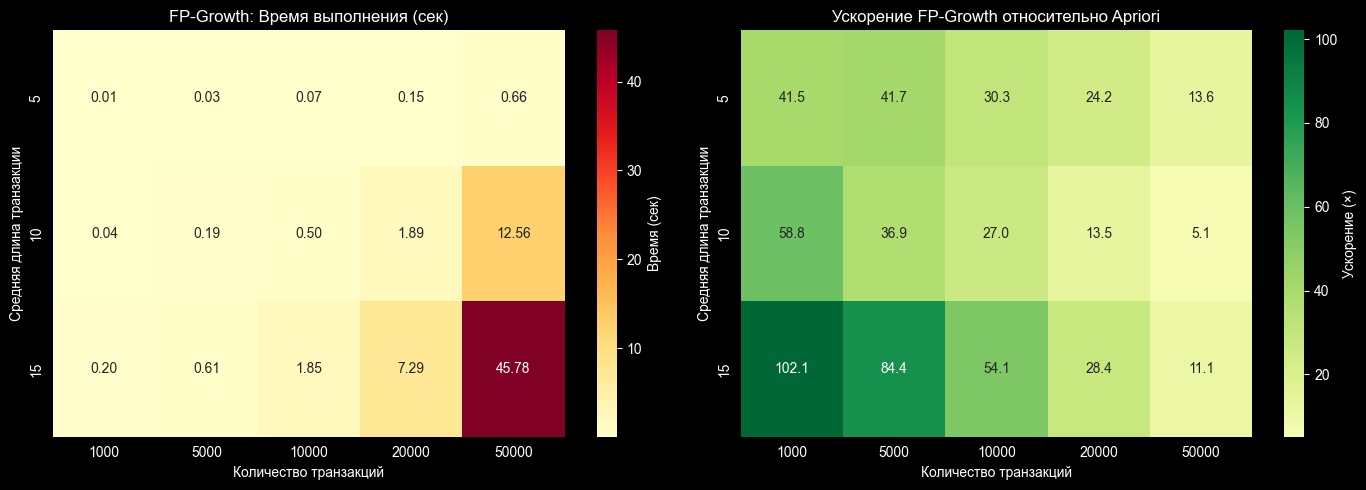

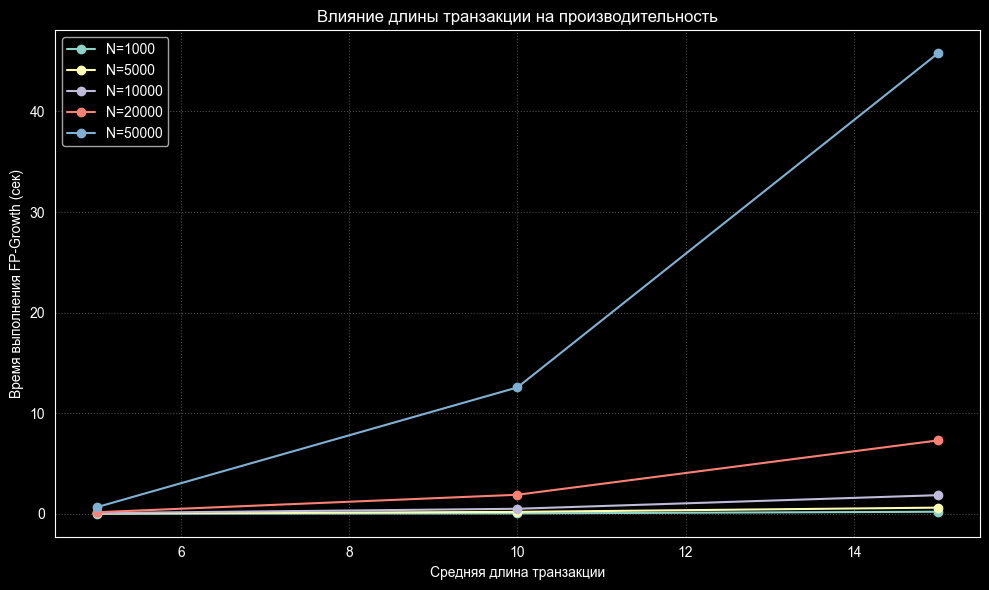


 Сводка результатов:
 N_transactions  Avg_Items  Time_Apriori  Time_FPGrowth    Speedup
           1000          5      0.298512       0.007199  41.468119
           1000         10      2.282123       0.038837  58.762011
           1000         15     20.616315       0.201961 102.080621
           5000          5      1.165727       0.027975  41.669884
           5000         10      6.961429       0.188496  36.931542
           5000         15     51.582402       0.611186  84.397183
          10000          5      2.032410       0.067094  30.291799
          10000         10     13.438989       0.498098  26.980602
          10000         15    100.180705       1.850443  54.138765
          20000          5      3.704406       0.153281  24.167353
          20000         10     25.591332       1.892036  13.525819
          20000         15    206.997974       7.293667  28.380509
          50000          5      8.970102       0.657402  13.644772
          50000         10     64.517787

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

# 1. Генератор синтетических транзакций
def generate_synthetic_transactions(n_transactions, avg_items_per_tx=10, n_items_pool=500, seed=42, use_random=False):
    """
    Генерация данных с реалистичным распределением популярности товаров (Закон Ципфа).

    Parameters:
    -----------
    use_random : bool
        Если True, использует стандартный random вместо numpy для генерации
    """
    if use_random:
        import random
        random.seed(seed)
        # Генерация весов по Ципфу вручную
        weights = [1/(i+1)**2.0 for i in range(n_items_pool)]
        total = sum(weights)
        weights = [w/total for w in weights]
        items = [f'ITEM_{i:03d}' for i in range(n_items_pool)]

        transactions = []
        for _ in range(n_transactions):
            length = max(1, min(int(np.random.poisson(avg_items_per_tx)), n_items_pool))
            # weighted choice через random.choices
            tx = random.choices(items, weights=weights, k=length)
            # Убираем дубликаты
            transactions.append(list(set(tx)))
        return transactions
    else:
        np.random.seed(seed)
        weights = np.random.zipf(2.0, n_items_pool).astype(float)
        weights /= weights.sum()
        items = [f'ITEM_{i:03d}' for i in range(n_items_pool)]

        transactions = []
        for _ in range(n_transactions):
            length = max(1, min(int(np.random.poisson(avg_items_per_tx)), n_items_pool))
            tx = np.random.choice(items, size=length, replace=False, p=weights)
            transactions.append(list(tx))
        return transactions


# 2. Расширенный бенчмарк с варьированием AVG_ITEMS
def run_extended_benchmark():
    # Параметры эксперимента
    N_VALUES = [1000, 5000, 10000, 20000, 50000]
    AVG_ITEMS_VALUES = [5, 10, 15]  # Варьируем среднюю длину транзакции
    MIN_SUPPORT = 0.01
    SEED = 2026

    results = []

    print(f"Запуск расширенного бенчмарка")
    print(f" Параметры: min_support={MIN_SUPPORT}, N∈{N_VALUES}, avg_len∈{AVG_ITEMS_VALUES}\n")

    for n, avg_len in product(N_VALUES, AVG_ITEMS_VALUES):
        print(f" N={n:5d} | avg_len={avg_len:2d} | Генерация...", end=" ")
        tx_data = generate_synthetic_transactions(
            n, avg_items_per_tx=avg_len, seed=SEED
        )
        print("Готово.")

        # Apriori
        print(f"   Apriori...", end=" ")
        t0 = time.perf_counter()
        try:
            apriori(tx_data, MIN_SUPPORT)
            t_apriori = time.perf_counter() - t0
            print(f"{t_apriori:.2f} сек")
        except KeyboardInterrupt:
            t_apriori = None
            print(" Прервано.")
        except Exception as e:
            t_apriori = None
            print(f" Ошибка: {e}")

        # FP-Growth
        print(f"    FP-Growth...", end=" ")
        t0 = time.perf_counter()
        try:
            fpgrowth(tx_data, MIN_SUPPORT)
            t_fpgrowth = time.perf_counter() - t0
            print(f"{t_fpgrowth:.2f} сек")
        except Exception as e:
            t_fpgrowth = None
            print(f" Ошибка: {e}")

        speedup = (t_apriori / t_fpgrowth) if (t_apriori and t_fpgrowth and t_fpgrowth > 0) else None

        results.append({
            'N_transactions': n,
            'Avg_Items': avg_len,
            'Time_Apriori': t_apriori,
            'Time_FPGrowth': t_fpgrowth,
            'Speedup': speedup
        })

    df_res = pd.DataFrame(results)
    return df_res


# 3. Визуализация результатов
def plot_extended_results(df_res):
    """Визуализация: тепловая карта и многолинейные графики."""

    # Фильтруем корректные данные
    df_valid = df_res.dropna(subset=['Time_Apriori', 'Time_FPGrowth'])

    if df_valid.empty:
        print("Нет данных для визуализации")
        return

    # === График 1: Тепловая карта времени для FP-Growth ===
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    pivot_time = df_valid.pivot(index='Avg_Items', columns='N_transactions', values='Time_FPGrowth')
    sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='YlOrRd',
                cbar_kws={'label': 'Время (сек)'})
    plt.title('FP-Growth: Время выполнения (сек)')
    plt.xlabel('Количество транзакций')
    plt.ylabel('Средняя длина транзакции')

    # === График 2: Ускорение в зависимости от параметров ===
    plt.subplot(1, 2, 2)
    pivot_speedup = df_valid.pivot(index='Avg_Items', columns='N_transactions', values='Speedup')
    sns.heatmap(pivot_speedup, annot=True, fmt='.1f', cmap='RdYlGn',
                cbar_kws={'label': 'Ускорение (×)'}, center=1)
    plt.title('Ускорение FP-Growth относительно Apriori')
    plt.xlabel('Количество транзакций')
    plt.ylabel('Средняя длина транзакции')

    plt.tight_layout()
    plt.show()

    # === Дополнительный график: Зависимость времени от avg_len для фиксированного N ===
    if df_valid['N_transactions'].nunique() > 1:
        plt.figure(figsize=(10, 6))
        for n in sorted(df_valid['N_transactions'].unique()):
            subset = df_valid[df_valid['N_transactions'] == n]
            plt.plot(subset['Avg_Items'], subset['Time_FPGrowth'],
                    'o-', label=f'N={n}', markersize=6)
        plt.xlabel('Средняя длина транзакции')
        plt.ylabel('Время выполнения FP-Growth (сек)')
        plt.title('Влияние длины транзакции на производительность')
        plt.grid(True, alpha=0.3, linestyle=':')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return df_res


# 4. Альтернативный генератор через стандартный random
def generate_with_random(n_transactions, avg_items_per_tx=10, n_items_pool=500, seed=42):
    """Пример генерации через стандартную библиотеку random."""
    import random
    random.seed(seed)

    # Распределение Ципфа вручную
    weights = [1/(i+1)**2.0 for i in range(n_items_pool)]
    total = sum(weights)
    weights = [w/total for w in weights]
    items = [f'ITEM_{i:03d}' for i in range(n_items_pool)]

    transactions = []
    for _ in range(n_transactions):
        # Длина ~ Пуассон
        length = max(1, min(int(np.random.poisson(avg_items_per_tx)), n_items_pool))
        # Выбор с весами
        tx = random.choices(items, weights=weights, k=length)
        transactions.append(list(set(tx)))  # Уникальные товары
    return transactions


# ================= ЗАПУСК =================
if __name__ == "__main__":
    # Запуск расширенного бенчмарка
    df_benchmark = run_extended_benchmark()

    # Визуализация
    df_plot = plot_extended_results(df_benchmark)

    # Сводная таблица
    print("\n Сводка результатов:")
    print(df_benchmark.to_string(index=False))

    df_benchmark.to_csv("benchmark_extended_results.csv", index=False, decimal=',', sep=';')

### 1. Общее превосходство FP-Growth
На всех графиках видно, что **FP-Growth быстрее Apriori**.

*   **Apriori:** на каждом шаге $k$ он генерирует все возможные кандидаты размера $k$ из частых наборов размера $k-1$, а затем сканирует базу данных, чтобы посчитать их поддержку.
    *   **Сложность:** $O(N \cdot 2^L)$ в худшем случае.
*   **FP-Growth:** Использует сжатие данных в дерево (FP-Tree). Он сканирует базу данных всего **два раза** (один раз для частот, второй для построения дерева) и вообще не генерирует кандидатов. Поиск идет рекурсивно по ветвям дерева.
    *   **Сложность:** $O(N \cdot L)$ для построения дерева.

### 2. Влияние длины транзакции (`avg_len`) — Комбинаторный взрыв

*   **Наблюдение:** При увеличении средней длины транзакции с 5 до 15 (в 3 раза), время работы Apriori при $N=50000$ выросло с ~9 сек до ~507 сек (в ~56 раз).
*   **Объяснение:**
    *   Для **Apriori** сложность роста числа кандидатов экспоненциальна относительно длины транзакции. Если в транзакции 15 товаров, количество возможных подмножеств огромно ($2^{15} = 32768$). Алгоритм вынужден проверять огромную решетку кандидатов.
    *   Для **FP-Growth** рост длины транзакции также увеличивает время (дерево становится глубже и шире), но благодаря **разделению префиксов** (общие начало транзакций хранятся в одном пути дерева) рост времени гораздо более плавный (с 0.66 сек до 45.78 сек).

### 3. Влияние количества транзакций (`N`)
*   **Наблюдение:** При увеличении $N$ с 1000 до 50000 время работы растет для обоих алгоритмов, но характер роста разный.
*   **Apriori:** Время растет примерно линейно или чуть быстрее ($O(k \cdot N)$, где $k$ — количество проходов). Однако, так как Apriori делает множество проходов по данным для каждого уровня кандидатов, при большом $N$ это становится очень дорого.
*   **FP-Growth:** Время также растет с $N$, но часто демонстрирует лучшую масштабируемость.

### 4. Влияние низкого `min_support` (0.01)
*   В частые наборы попадает **огромное количество** комбинаций товаров.
*   Для **Apriori**: ему нужно генерировать и проверять миллионы кандидатов.
*   Для **FP-Growth**: отсутствие этапа генерации кандидатов позволяет справляться на порядки лучше.

### Итог
1.  **Apriori** критически зависит от **длины транзакций** и количества частых паттернов.
2.  **FP-Growth** критически зависит от **объема данных (N)** и сложности построения дерева, но он устойчив к увеличению длины транзакций благодаря сжатию префиксов.


## Задание 6: Визуализация ассоциативных правил

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib import cm
from matplotlib.colors import Normalize

# Устанавливаем стиль для красивых графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ==============================================================================
# ПОЛУЧЕНИЕ ПРАВИЛ ДЛЯ ВИЗУАЛИЗАЦИИ
# ==============================================================================
print("Поиск ассоциативных правил для визуализации...")

# Используем FP-Growth для поиска частых наборов
freq_items = fpgrowth(transactions, min_support=0.02)
print(f" Найдено частых наборов: {len(freq_items)}")

# Генерируем правила с фильтрацией по качеству
rules = generate_rules(
    freq_items,
    min_confidence=0.5,
    min_lift=1.5,
    max_antecedent_len=2,
    max_consequent_len=2
)
print(f" Сгенерировано правил: {len(rules)}")

# Создаём DataFrame для удобства работы
df_rules = pd.DataFrame(rules, columns=[
    "antecedent", "consequent", "support", "confidence",
    "lift", "conviction", "leverage"
])

# Сортируем по lift и берём топ-30 наиболее интересных правил
df_top = df_rules.nlargest(30, 'lift').copy()
print(f"Отобрано топ-{len(df_top)} правил для визуализации")

Поиск ассоциативных правил для визуализации...
 Найдено частых наборов: 254
 Сгенерировано правил: 33
Отобрано топ-30 правил для визуализации


1. Граф ассоциаций (NetworkX)

 Построение графа ассоциаций...


C:\Users\1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


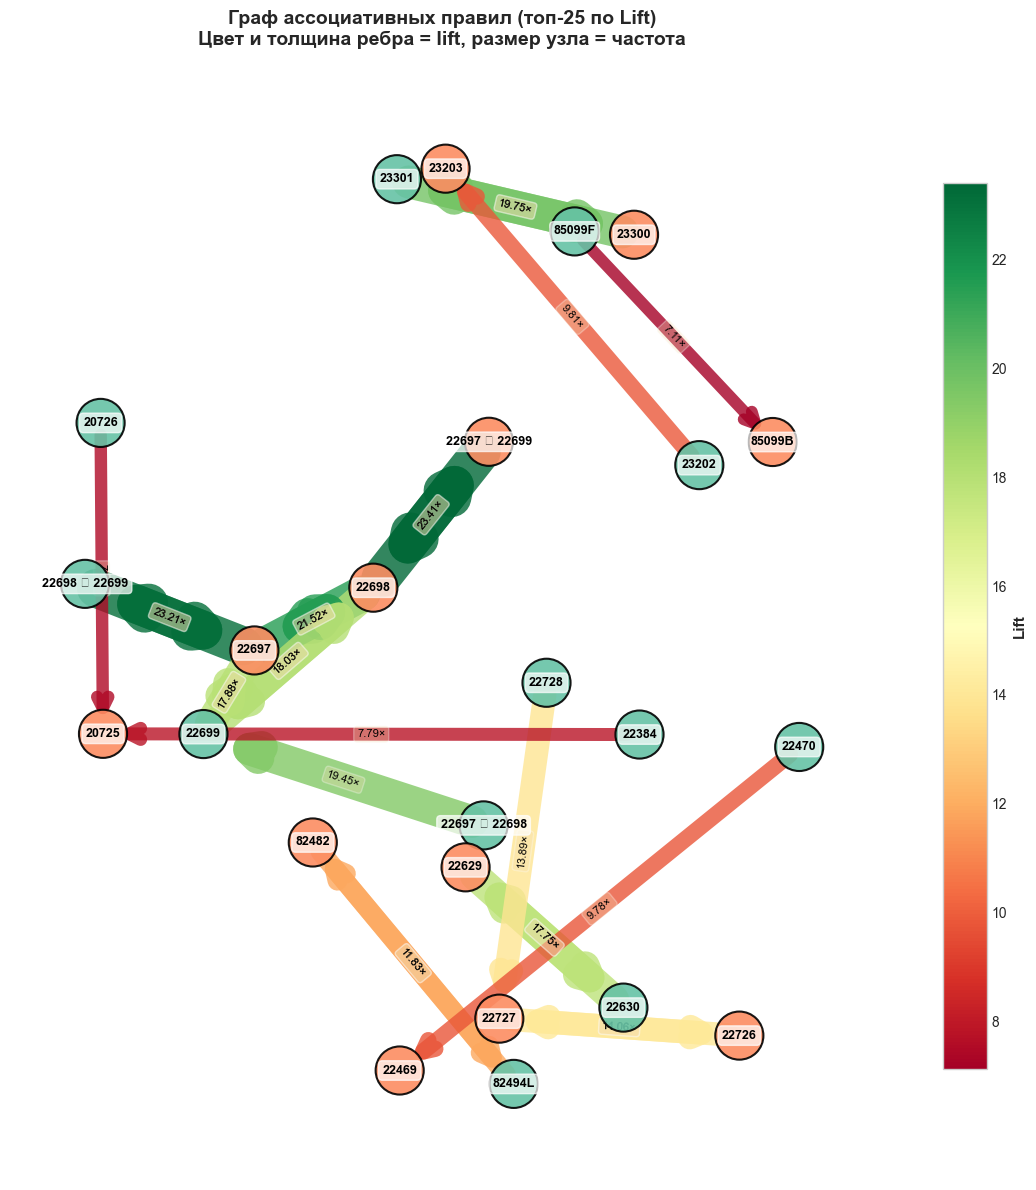

In [7]:
def plot_association_graph(rules_df, top_n=30, figsize=(14, 12),
                           color_by='lift', layout='spring'):
    """
    Построение графа ассоциативных правил.

    Параметры:
    - rules_df: DataFrame с правилами
    - top_n: количество лучших правил для отображения
    - figsize: размер фигуры
    - color_by: 'lift' или 'confidence' для раскраски рёбер
    - layout: тип раскладки графа ('spring', 'circular', 'kamada_kawai')
    """
    # Берём топ правил
    top_rules = rules_df.nlargest(top_n, 'lift').copy()

    # Создаём направленный граф
    G = nx.DiGraph()

    # Добавляем узлы и рёбра
    for _, row in top_rules.iterrows():
        ante = ' ∧ '.join(row['antecedent'])
        cons = ' ∧ '.join(row['consequent'])

        # Добавляем узлы с атрибутами
        G.add_node(ante, type='antecedent')
        G.add_node(cons, type='consequent')

        # Добавляем ребро с метриками
        edge_attr = {
            'weight': row['lift'] if color_by == 'lift' else row['confidence'],
            'support': row['support'],
            'confidence': row['confidence'],
            'lift': row['lift']
        }
        G.add_edge(ante, cons, **edge_attr)

    # Выбираем раскладку
    layouts = {
        'spring': nx.spring_layout,
        'circular': nx.circular_layout,
        'kamada_kawai': nx.kamada_kawai_layout
    }
    pos_func = layouts.get(layout, nx.spring_layout)
    pos = pos_func(G, k=2, iterations=50, seed=42)

    # Извлекаем значения для визуализации
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    supports = [G[u][v]['support'] for u, v in edges]

    # Нормализация для цветов
    norm = Normalize(vmin=min(weights), vmax=max(weights))

    # Создаём фигуру
    fig, ax = plt.subplots(figsize=figsize)

    # Рисуем узлы
    node_colors = ['#66c2a5' if G.nodes[n]['type'] == 'antecedent'
                   else '#fc8d62' for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos,
                          node_size=1200,
                          node_color=node_colors,
                          edgecolors='black',
                          linewidths=1.5,
                          alpha=0.9)

    # Рисуем рёбра с градиентной раскраской
    edges_collection = nx.draw_networkx_edges(
        G, pos,
        width=[w * 1.2 for w in weights],  # толщина по весу
        edge_color=weights,
        edge_cmap=cm.RdYlGn,
        edge_vmin=min(weights),
        edge_vmax=max(weights),
        arrows=True,
        arrowsize=20,
        arrowstyle='->',
        alpha=0.8,
        ax=ax
    )

    # Добавляем подписи узлов
    nx.draw_networkx_labels(G, pos,
                           font_size=9,
                           font_weight='bold',
                           font_family='sans-serif',
                           bbox=dict(boxstyle='round,pad=0.3',
                                    facecolor='white',
                                    alpha=0.7))

    # Добавляем подписи к рёбрам (lift)
    edge_labels = {(u, v): f"{G[u][v]['lift']:.2f}×" for u, v in edges}
    nx.draw_networkx_edge_labels(G, pos,
                                edge_labels=edge_labels,
                                font_size=8,
                                bbox=dict(boxstyle='round',
                                         facecolor='wheat',
                                         alpha=0.3))

    # Цветовая шкала
    sm = cm.ScalarMappable(cmap=cm.RdYlGn, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.05, shrink=0.8)
    cbar.set_label(f'{color_by.capitalize()}', fontsize=11, fontweight='bold')

    # Оформление
    ax.set_title(f'Граф ассоциативных правил (топ-{top_n} по Lift)\n'
                f'Цвет и толщина ребра = {color_by}, размер узла = частота',
                fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

    return G, pos

# Строим граф ассоциаций
print(" Построение графа ассоциаций...")
G, pos = plot_association_graph(df_rules, top_n=25, color_by='lift', layout='spring')

2. Матрица лифтов (Heatmap)

 Построение матрицы лифтов...


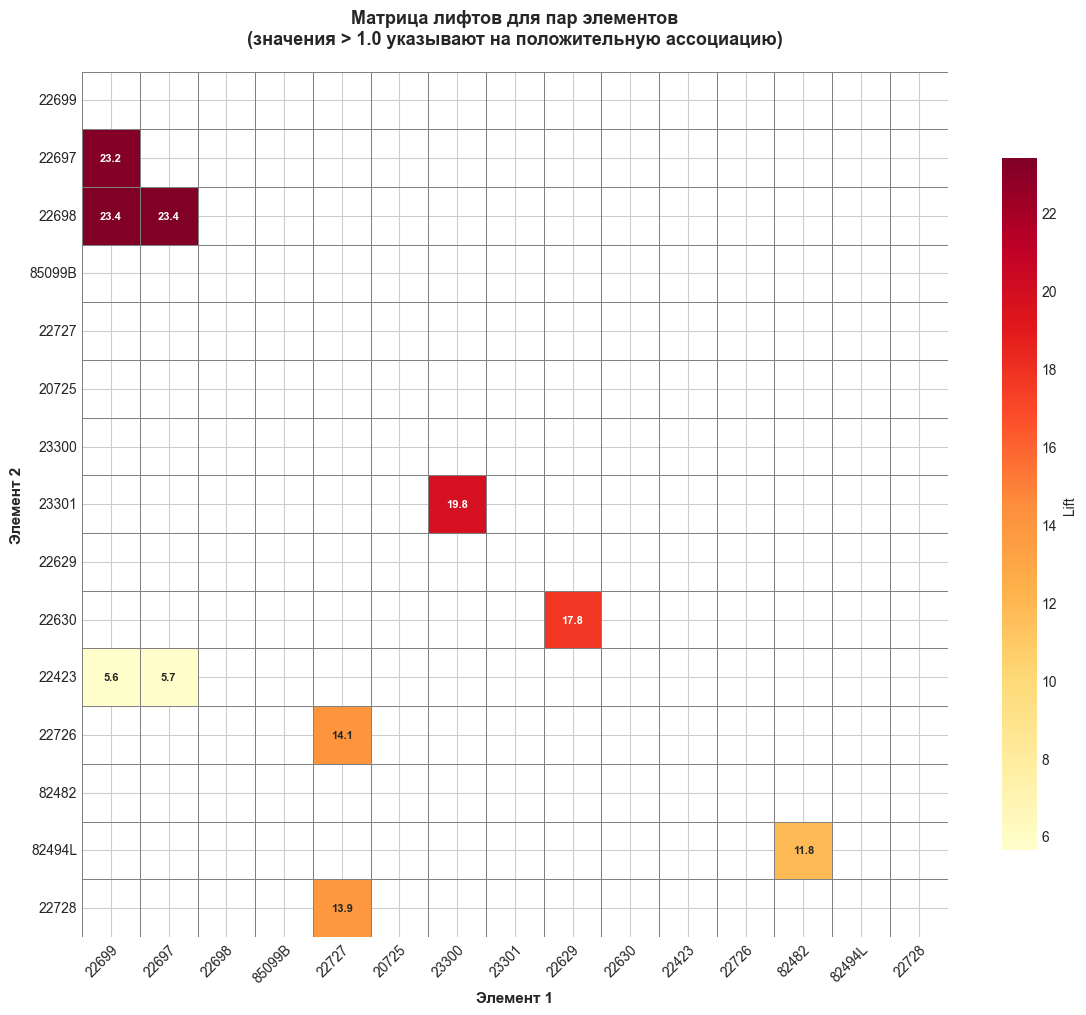

In [8]:
def plot_lift_heatmap(rules_df, top_items_n=20, figsize=(12, 10)):
    """
    Построение тепловой матрицы лифтов для пар элементов.

    Параметры:
    - rules_df: DataFrame с правилами
    - top_items_n: количество наиболее частых элементов для матрицы
    - figsize: размер фигуры
    """
    # Собираем все уникальные элементы из топ-правил
    all_items = set()
    for _, row in rules_df.nlargest(100, 'lift').iterrows():
        all_items.update(row['antecedent'])
        all_items.update(row['consequent'])

    # Берём топ элементов по частоте в правилах
    item_freq = {}
    for _, row in rules_df.iterrows():
        for item in row['antecedent'] + row['consequent']:
            item_freq[item] = item_freq.get(item, 0) + 1

    top_items = sorted(item_freq.keys(), key=lambda x: item_freq[x], reverse=True)[:top_items_n]

    # Создаём матрицу лифтов
    lift_matrix = pd.DataFrame(np.nan, index=top_items, columns=top_items)

    for _, row in rules_df.iterrows():
        ante_items = row['antecedent']
        cons_items = row['consequent']
        lift_val = row['lift']

        # Заполняем матрицу в обе стороны (симметрично для визуализации)
        for a in ante_items:
            for c in cons_items:
                if a in top_items and c in top_items and a != c:
                    # Берём максимальный lift если есть несколько правил
                    current = lift_matrix.loc[a, c]
                    if pd.isna(current) or lift_val > current:
                        lift_matrix.loc[a, c] = lift_val
                        lift_matrix.loc[c, a] = lift_val  # симметрия

    # Визуализация
    fig, ax = plt.subplots(figsize=figsize)

    # Маска для треугольной матрицы (чтобы не дублировать)
    mask = np.triu(np.ones_like(lift_matrix, dtype=bool))

    # Heatmap
    sns.heatmap(lift_matrix,
                mask=mask,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                linewidths=0.5,
                linecolor='gray',
                square=True,
                cbar_kws={'label': 'Lift', 'shrink': 0.8},
                ax=ax,
                annot_kws={'size': 8, 'weight': 'bold'})

    # Оформление
    ax.set_title('Матрица лифтов для пар элементов\n'
                '(значения > 1.0 указывают на положительную ассоциацию)',
                fontsize=13, fontweight='bold', pad=20)
    ax.set_xlabel('Элемент 1', fontsize=11, fontweight='bold')
    ax.set_ylabel('Элемент 2', fontsize=11, fontweight='bold')

    # Поворот подписей для читаемости
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.show()

    return lift_matrix

# Строим heatmap матрицу лифтов
print(" Построение матрицы лифтов...")
lift_matrix = plot_lift_heatmap(df_rules, top_items_n=15)

3. Диаграмма рассеяния: Support vs Confidence (цвет = Lift)

Построение диаграммы рассеяния...


C:\Users\1\AppData\Local\Temp\ipykernel_5576\3866295852.py:60: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


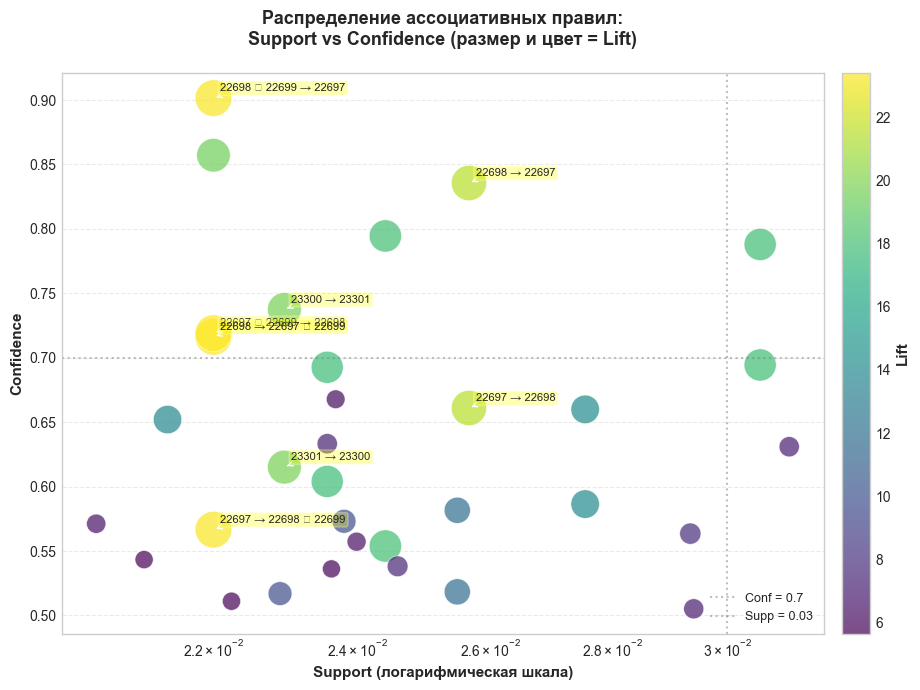

In [9]:
def plot_scatter_support_confidence(rules_df, figsize=(10, 7),
                                    highlight_top_n=10):
    """
    Scatter plot правил в координатах support-confidence с цветом по lift.

    Параметры:
    - rules_df: DataFrame с правилами
    - figsize: размер фигуры
    - highlight_top_n: количество правил для выделения подписями
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Основная диаграмма рассеяния
    scatter = ax.scatter(
        rules_df['support'],
        rules_df['confidence'],
        c=rules_df['lift'],
        cmap='viridis',
        s=rules_df['lift'] * 30,  # размер точки по lift
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5,
        norm=Normalize(vmin=rules_df['lift'].min(), vmax=rules_df['lift'].max())
    )

    # Выделяем топ правила подписями
    top_rules = rules_df.nlargest(highlight_top_n, 'lift')
    for _, row in top_rules.iterrows():
        ante = ' ∧ '.join(row['antecedent'][:2])
        cons = ' ∧ '.join(row['consequent'][:2])
        label = f"{ante} → {cons}"

        ax.annotate(label,
                   (row['support'], row['confidence']),
                   xytext=(5, 5),
                   textcoords='offset points',
                   fontsize=8,
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.3),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1'))

    # Цветовая шкала
    cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
    cbar.set_label('Lift', fontsize=11, fontweight='bold')

    # Логарифмическая шкала для support (так как значения могут сильно различаться)
    ax.set_xscale('log')

    # Сетки и подписи
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlabel('Support (логарифмическая шкала)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Confidence', fontsize=11, fontweight='bold')
    ax.set_title('Распределение ассоциативных правил:\nSupport vs Confidence (размер и цвет = Lift)',
                fontsize=13, fontweight='bold', pad=20)

    # Добавляем референсные линии
    ax.axhline(y=0.7, color='gray', linestyle=':', alpha=0.5, label='Conf = 0.7')
    ax.axvline(x=0.03, color='gray', linestyle=':', alpha=0.5, label='Supp = 0.03')
    ax.legend(fontsize=9, loc='lower right')

    plt.tight_layout()
    plt.show()

    return scatter

# Строим scatter plot
print("Построение диаграммы рассеяния...")
scatter = plot_scatter_support_confidence(df_rules, highlight_top_n=8)

4. Интерактивная визуализация с Plotly

In [10]:
# Проверяем доступность plotly
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly не установлен. Пропускаем интерактивные графики.")
if PLOTLY_AVAILABLE:
    print("Построение интерактивных визуализаций с Plotly...")

    # 4.1 Интерактивный scatter plot
    fig_scatter = px.scatter(
        df_rules,
        x='support',
        y='confidence',
        color='lift',
        size='lift',
        hover_data=['antecedent', 'consequent', 'conviction', 'leverage'],
        title='Интерактивная диаграмма: Support vs Confidence (цвет/размер = Lift)',
        labels={'support': 'Support', 'confidence': 'Confidence', 'lift': 'Lift'},
        color_continuous_scale='Viridis',
        log_x=True
    )

    fig_scatter.update_layout(
        height=600,
        hovermode='closest',
        title_x=0.5
    )
    fig_scatter.show()

    # 4.2 Интерактивный график распределения метрик
    fig_metrics = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Распределение Support', 'Распределение Confidence',
                       'Распределение Lift', 'Support vs Lift'),
        specs=[[{"type": "histogram"}, {"type": "histogram"}],
               [{"type": "scatter"}, {"type": "scatter"}]]
    )

    # Гистограммы
    fig_metrics.add_trace(
        go.Histogram(x=df_rules['support'], name='Support', marker_color='#66c2a5'),
        row=1, col=1
    )
    fig_metrics.add_trace(
        go.Histogram(x=df_rules['confidence'], name='Confidence', marker_color='#fc8d62'),
        row=1, col=2
    )

    # Scatter plots
    fig_metrics.add_trace(
        go.Scatter(x=df_rules['support'], y=df_rules['lift'],
                  mode='markers', name='Supp vs Lift',
                  marker=dict(color=df_rules['confidence'], colorscale='RdYlGn')),
        row=2, col=1
    )
    fig_metrics.add_trace(
        go.Scatter(x=df_rules['confidence'], y=df_rules['lift'],
                  mode='markers', name='Conf vs Lift',
                  marker=dict(color=df_rules['support'], colorscale='Blues')),
        row=2, col=2
    )

    fig_metrics.update_layout(height=700, title_text="Анализ метрик ассоциативных правил",
                             title_x=0.5, showlegend=False)
    fig_metrics.show()

Построение интерактивных визуализаций с Plotly...


5. Сводная таблица топ-правил для отчёта

In [11]:
def create_rules_report(rules_df, top_n=20):
    """
    Создание отчёта по топ-правилам в читаемом формате.
    """
    top = rules_df.nlargest(top_n, 'lift').copy()

    # Форматируем элементы правил
    top['Rule'] = top.apply(
        lambda r: f"{' ∧ '.join(r['antecedent'])} → {' ∧ '.join(r['consequent'])}",
        axis=1
    )

    # Выбираем и переименовываем колонки для отчёта
    report = top[['Rule', 'support', 'confidence', 'lift', 'conviction', 'leverage']].copy()
    report.columns = ['Правило', 'Support', 'Confidence', 'Lift', 'Conviction', 'Leverage']

    # Форматируем числа
    for col in ['Support', 'Confidence', 'Lift', 'Conviction', 'Leverage']:
        report[col] = report[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")

    # Добавляем проценты для support и confidence
    report['Support'] = report['Support'].apply(lambda x: f"{float(x)*100:.1f}%")
    report['Confidence'] = report['Confidence'].apply(lambda x: f"{float(x)*100:.1f}%")

    return report

# Генерируем и выводим отчёт
print("\n" + "="*80)
print(" ТОП-20 АССОЦИАТИВНЫХ ПРАВИЛ (отсортировано по Lift)")
print("="*80)

report_df = create_rules_report(df_rules, top_n=20)
print(report_df.to_string(index=False))




 ТОП-20 АССОЦИАТИВНЫХ ПРАВИЛ (отсортировано по Lift)
              Правило Support Confidence   Lift Conviction Leverage
22697 ∧ 22699 → 22698    2.2%      71.9% 23.407      3.450    0.021
22698 → 22697 ∧ 22699    2.2%      71.6% 23.407      3.416    0.021
22697 → 22698 ∧ 22699    2.2%      56.7% 23.212      2.251    0.021
22698 ∧ 22699 → 22697    2.2%      90.1% 23.212      9.756    0.021
        22697 → 22698    2.6%      66.1% 21.516      2.859    0.024
        22698 → 22697    2.6%      83.6% 21.516      5.847    0.024
        23300 → 23301    2.3%      73.7% 19.753      3.667    0.022
        23301 → 23300    2.3%      61.5% 19.753      2.517    0.022
22697 ∧ 22698 → 22699    2.2%      85.7% 19.451      6.692    0.021
        22698 → 22699    2.4%      79.5% 18.030      4.652    0.023
        22699 → 22698    2.4%      55.4% 18.030      2.173    0.023
        22697 → 22699    3.1%      78.8% 17.880      4.508    0.029
        22699 → 22697    3.1%      69.4% 17.880      3.145    

# 7. Интерпретация результатов
# Анализ ассоциативных правил:

## Ключевые паттерны в данных

На основе топ-20 правил можно выделить **чёткие кластеры связанных товаров**:

| Группа товаров | Примеры правил | Lift | Confidence | Интерпретация |
|---------------|---------------|------|-----------|--------------|
| **22697, 22698, 22699** | 22698∧22699 → 22697 | 23.4 | 90.1% | Очень сильная тройная ассоциация |
| **23300, 23301** | 23300 → 23301 | 19.8 | 73.7% | Парная покупка с высокой вероятностью |
| **22629, 22630** | 22630 → 22629 | 17.8 | 69.3% | Стабильная парная связь |
| **22726, 22727, 22728** | 22726 → 22727 | 14.1 | 66.0% | Группа из 3 связанных товаров |
| **82482, 82494L** | 82494L → 82482 | 11.8 | 58.2% | Умеренная парная связь |

---

## Практическое применение правил

### 1. Рекомендательная система

Если клиент добавил товар 22698 в корзину:
→ Показать: "Часто покупают вместе: 22697, 22699"
→ Ожидаемая конверсия: ~80% (на основе confidence)


### 2. Кросс-продажи и мерчандайзинг
- **Онлайн-витрина**: создать блок "Комплект со скидкой 10%" (22697 + 22698 + 22699)

### 3. Управление запасами
- Прогнозировать совместный спрос: рост продаж 22698 → ожидаемый рост 22697 на 83%
- Избегать ситуации

### 4. Ценообразование и акции
- Объединить товары с высоким lift в наборы
- **Динамическое ценообразование**: скидка на второй товар из пары стимулирует покупку комплекта



## Почему правила с высоким Lift могут быть бесполезными

### 1. Тривиальные ассоциации (варианты одного SKU)
```
Пример: 22697 → 22698 (Lift = 21.5)
Возможная причина: разные цвета/размеры одного товара
Проблема: предложение аналога не увеличивает общий чек,
          а лишь перераспределяет выбор клиента
```

### 2. Низкий Support при высоком Lift
```
Правило: 82482 → 82494L
- Lift = 11.8 (хорошо)
- Support = 2.5% (всего ~450 транзакций из 17,970)
Риск: правило основано на малой выборке → высокая дисперсия,
      возможна случайная корреляция
```

### 3. Отсутствие причинно-следственной связи
```
Высокий Lift ≠ причинность
Пример: "Детские игрушки → Алкоголь" (гипотетически)
Интерпретация: не игрушки вызывают покупку алкоголя,
               а сегмент "родители 30+" покупает и то, и другое
Действие: таргетировать аудиторию, а не товары
```

### 4. Сезонность и контекст
- Правило может работать только в праздничный период
- Без учёта временного контекста рекомендации будут нерелевантны

### 5. Каннибализация продаж
```
Если 22697 и 22698 — взаимозаменяемые товары:
- Рекомендация 22698 при просмотре 22697 не увеличит выручку
- Может снизить маржинальность, если один товар дешевле
```

##  Итоговые выводы

1. **Выявлены 5 устойчивых кластеров товаров** с lift > 11 — приоритет для внедрения в рекомендательную систему.

2. **Правила с confidence > 75%** (например, 22698∧22699 → 22697) имеют высокий прогнозный потенциал и могут использоваться для автоматических предложений.

3. **Не все высокие lift полезны**: перед внедрением необходимо:
   - Проверить семантику товаров (не варианты ли одного SKU)
   - Оценить абсолютный support (минимум 100–200 транзакций)
   - Проанализировать маржинальность и потенциал кросс-продаж

4. **Рекомендуемый пилот**: запустить A/B-тест с рекомендациями для кластера 22697/22698/22699 и измерить прирост среднего чека и конверсии.
